# 40.01 Обработка ТТРКГ эксперимента 2

## Задача

Ноутбук принимает 19 независимых записей эксперимента 2, уже созданную
дыхательную и ЭКГ-разметку и строит знаковые ЭКГ-синхронизированные ансамбли
канала ТТРКГ (`BASE1/RHEO1`). Записи разных размеров боковой сборки сделаны
последовательно и не считаются одновременными повторностями.

По принятому правилу проекта численные выходы прибора используются в заявленных
единицах: `BASE1` — в омах, `RHEO1` — в миллиомах с переводом `0,001 Ом/мОм`.
Дополнительные gain, offset и инверсия знака не вводятся. Это не метрологическая
калибровка, а работа с сигналом «как зарегистрирован прибором».

Групповая задержка тракта не измерена. Поэтому шкала времени остаётся временем
записи относительно найденного R-зубца; абсолютную физиологическую задержку по
этим кривым пока оценивать нельзя.


In [1]:
from __future__ import annotations

import hashlib
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from ttrkg_analysis import ensemble_waveform, robust_signal_metrics

REAL_MODE = os.environ.get("KALMYKOV_RUN_REAL", "0") == "1"
EXPLORATORY_MODE = os.environ.get("KALMYKOV_RUN_EXPLORATORY", "0") == "1"


def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def status_allowed(status):
    return status == "accepted" or (EXPLORATORY_MODE and status == "pending_manual_review")


def discover_record_manifest(config, experiment_id, expected_pairs=None, expected_ids=None):
    spec = config.get("record_manifest", {})
    if spec.get("path") and Path(spec["path"]).is_file():
        path = Path(spec["path"]).expanduser().resolve()
        item = json.loads(path.read_text(encoding="utf-8"))
        if status_allowed(item.get("status")):
            return path, item
    if not EXPLORATORY_MODE:
        raise RuntimeError("Не задан принятый QC-манифест записей")
    derived_root = Path(config["derived_root"]).expanduser().resolve()
    matches = []
    required = {
        "record_id", "subject_id", "relative_path", "input_sha256",
        "actual_active_channels", "include", "qc_status", "configuration_id",
        "montage_id", "side_montage_id", "side_size_mm",
    }
    for path in sorted((derived_root / experiment_id / "qc").glob("*.json")):
        item = json.loads(path.read_text(encoding="utf-8"))
        rows = item.get("records", [])
        if not rows or not required.issubset(rows[0]):
            continue
        included = [row for row in rows if row.get("include") is True]
        ids = {row.get("record_id") for row in included}
        pairs = {(row.get("subject_id"), int(row["side_size_mm"])) for row in included if row.get("side_size_mm") is not None}
        if expected_ids is not None and ids != set(expected_ids):
            continue
        if expected_pairs is not None and pairs != set(expected_pairs):
            continue
        matches.append((path, item))
    if len(matches) != 1:
        raise RuntimeError(f"Ожидался один кандидатный QC-манифест, найдено {len(matches)}")
    return matches[0]


def load_sidecars(directory, annotation_type):
    result = {}
    for path in sorted(Path(directory).glob("*.json")):
        item = json.loads(path.read_text(encoding="utf-8"))
        if item.get("annotation_type") != annotation_type:
            continue
        status = item.get("qc", {}).get("status")
        if not status_allowed(status):
            continue
        record_id = item.get("record_id")
        if not record_id or record_id in result:
            raise RuntimeError("Пустой или повторный record_id в разметке")
        result[record_id] = (path, item)
    return result


def breathing_modes(item):
    accepted = item.get("accepted_modes") or {}
    if item.get("qc", {}).get("status") == "accepted" and accepted:
        return {str(name): tuple(map(float, span)) for name, span in accepted.items()}, "accepted"
    if not EXPLORATORY_MODE:
        return {}, "unavailable"
    candidate = item.get("candidate_modes") or []
    if isinstance(candidate, dict):
        return {str(name): tuple(map(float, span)) for name, span in candidate.items()}, "pending_manual_review"
    modes = {
        str(row["mode"]): (float(row["start_s"]), float(row["stop_s"]))
        for row in candidate
        if {"mode", "start_s", "stop_s"}.issubset(row)
    }
    return modes, "pending_manual_review"


def ecg_peaks(item):
    status = item.get("qc", {}).get("status")
    if status == "accepted" and item.get("rpeaks_s"):
        return np.asarray(item["rpeaks_s"], dtype=float), "accepted"
    if EXPLORATORY_MODE and item.get("candidate_rpeaks_s"):
        return np.asarray(item["candidate_rpeaks_s"], dtype=float), "pending_manual_review"
    return np.asarray([], dtype=float), "unavailable"


def reported_ttrkg_operator(config):
    source = config.get("ttrkg_analysis", {})
    required = {"signal_column", "base_column", "unit_scale_to_ohm", "pre_s", "post_s", "grid_step_s", "baseline_s", "hold_margin_s"}
    if not required.issubset(source):
        raise RuntimeError("В ttrkg_analysis отсутствуют обязательные технические поля")
    scale = float(source["unit_scale_to_ohm"])
    if not np.isfinite(scale) or scale <= 0.0:
        raise ValueError("unit_scale_to_ohm должен быть положительным")
    delay = source.get("group_delay_s")
    delay_known = delay is not None and np.isfinite(float(delay))
    return {
        "signal_column": source["signal_column"],
        "base_column": source["base_column"],
        "unit_scale_to_ohm": scale,
        "sign": 1.0 if source.get("sign") is None else float(source["sign"]),
        "gain": 1.0 if source.get("gain") is None else float(source["gain"]),
        "base_sign": 1.0 if source.get("base_sign") is None else float(source["base_sign"]),
        "base_gain": 1.0 if source.get("base_gain") is None else float(source["base_gain"]),
        "base_offset_ohm": 0.0 if source.get("base_offset_ohm") is None else float(source["base_offset_ohm"]),
        "pre_s": float(source["pre_s"]),
        "post_s": float(source["post_s"]),
        "grid_step_s": float(source["grid_step_s"]),
        "baseline_s": tuple(map(float, source["baseline_s"])),
        "hold_margin_s": float(source["hold_margin_s"]),
        "group_delay_correction_s": float(delay) if delay_known else 0.0,
        "timing_status": "measured_and_corrected" if delay_known else "not_measured_not_corrected",
        "signal_policy": "instrument_reported_units_identity_transform",
    }


def annotation_quality(ecg_item, pulse_metrics):
    peaks, ecg_status = ecg_peaks(ecg_item)
    max_rr = float(np.max(np.diff(peaks))) if len(peaks) >= 2 else None
    warnings = []
    if ecg_status != "accepted":
        warnings.append("ЭКГ-разметка не принята вручную")
    if max_rr is not None and max_rr > 2.0:
        warnings.append("в кандидатной ЭКГ-разметке есть интервал более 2 с без R-зубца")
    if pulse_metrics["fraction_at_exact_extremes"] > 0.005:
        warnings.append("повторяются точные крайние уровни RHEO; причина не установлена")
    return peaks, ecg_status, max_rr, warnings


In [2]:
if not REAL_MODE:
    print("40.01: выполнена только структурная часть; для внешних данных задайте KALMYKOV_RUN_REAL=1")
else:
    config_path = Path(os.environ["KALMYKOV_EXP02_CONFIG"]).expanduser().resolve()
    config = json.loads(config_path.read_text(encoding="utf-8"))
    operator = reported_ttrkg_operator(config)
    expected_pairs = {(subject["subject_id"], int(size_mm)) for subject in config["subjects"] for size_mm in subject["sizes_mm"]}
    manifest_path, manifest = discover_record_manifest(config, "exp02", expected_pairs=expected_pairs)
    records = {row["record_id"]: row for row in manifest["records"] if row.get("include") is True}
    if len(records) != int(config["expected_independent_record_count"]):
        raise RuntimeError("QC-манифест не содержит ровно 19 независимых записей")
    if any(row["actual_active_channels"] != [1, 2] for row in records.values()):
        raise RuntimeError("В эксперименте 2 ожидаются фактически активные каналы 1 и 2")

    derived_root = Path(config["derived_root"]).expanduser().resolve()
    data_root = Path(config["data_root"]).expanduser().resolve()
    breathing = load_sidecars(derived_root / "exp02" / "annotations" / "breathing", "breathing")
    ecg = load_sidecars(derived_root / "exp02" / "annotations" / "ecg", "ecg")
    breathing_by_sha = {item["input"]["sha256"]: (path, item) for path, item in breathing.values()}
    ecg_by_sha = {item["input"]["sha256"]: (path, item) for path, item in ecg.values()}
    record_hashes = {row["input_sha256"] for row in records.values()}
    if len(breathing_by_sha) != len(breathing) or len(ecg_by_sha) != len(ecg):
        raise RuntimeError("В разметке повторяется SHA-256 исходного файла")
    if set(breathing_by_sha) != record_hashes or set(ecg_by_sha) != record_hashes:
        raise RuntimeError("Наборы записей, дыхательной и ЭКГ-разметки не совпадают по SHA-256")

    decisions_by_sha = {}
    for path in sorted((derived_root / "exp02" / "qc").glob("*.json")):
        candidate = json.loads(path.read_text(encoding="utf-8"))
        rows = candidate.get("records", [])
        if rows and "component_use" in rows[0]:
            decisions_by_sha = {row["input_sha256"]: row["component_use"] for row in rows}
            decision_manifest_path = path
            break
    if set(decisions_by_sha) != record_hashes:
        raise RuntimeError("Не найден полный субъектный реестр решений 12.01")

    raw_grid_s = np.arange(-operator["pre_s"], operator["post_s"] + 0.5 * operator["grid_step_s"], operator["grid_step_s"])
    reported_grid_s = raw_grid_s - operator["group_delay_correction_s"]
    outputs, failures, summary_rows = [], [], []
    for record_id, record in sorted(records.items()):
        breath_path, breath_item = breathing_by_sha[record["input_sha256"]]
        ecg_path, ecg_item = ecg_by_sha[record["input_sha256"]]
        if breath_item["input"]["sha256"] != record["input_sha256"] or ecg_item["input"]["sha256"] != record["input_sha256"]:
            raise RuntimeError("SHA-256 разметки не совпал с QC-манифестом")
        source = (data_root / record["relative_path"]).resolve()
        source.relative_to(data_root)
        if sha256_file(source) != record["input_sha256"]:
            raise RuntimeError("Исходный CSV изменился после QC")
        frame = pd.read_csv(source, encoding="utf-8")
        time_s = pd.to_numeric(frame["TIME_s"], errors="raise").to_numpy(float)
        pulse_raw = pd.to_numeric(frame[operator["signal_column"]], errors="raise").to_numpy(float)
        base_raw = pd.to_numeric(frame[operator["base_column"]], errors="raise").to_numpy(float)
        pulse_ohm = operator["sign"] * operator["gain"] * operator["unit_scale_to_ohm"] * pulse_raw
        base_ohm = operator["base_sign"] * operator["base_gain"] * base_raw + operator["base_offset_ohm"]
        modes, breath_status = breathing_modes(breath_item)
        selected_modes = {name: modes[name] for name in ("задержка_вдох", "задержка_выдох") if name in modes}
        if len(selected_modes) != 2:
            raise RuntimeError("Для записи эксперимента 2 не найдены обе принятые задержки дыхания")
        pulse_metrics = robust_signal_metrics(pulse_ohm)
        rpeaks, ecg_status, max_rr_s, record_warnings = annotation_quality(ecg_item, pulse_metrics)
        if len(rpeaks) < 3:
            raise RuntimeError("Для принятой записи найдено менее трёх R-зубцов")
        component_decision = decisions_by_sha[record["input_sha256"]]
        use_ttrkg = bool(component_decision.get("BASE1")) and bool(component_decision.get("RHEO1"))
        recommendation = "учитывать_условно" if use_ttrkg else "не_использовать_BASE1_RHEO1_количественно_по_решению_12.01"
        for mode, (left, right) in selected_modes.items():
            margin = operator["hold_margin_s"]
            interval = (left + margin, right - margin)
            mode_mask = (time_s >= interval[0]) & (time_s <= interval[1])
            if mode_mask.sum() < 10:
                failures.append({"record_id": record_id, "mode": mode, "reason": "слишком короткий интервал"})
                continue
            try:
                ensemble = ensemble_waveform(time_s, pulse_ohm, rpeaks, interval, raw_grid_s, operator["baseline_s"])
            except RuntimeError as error:
                failures.append({"record_id": record_id, "mode": mode, "reason": str(error)})
                continue
            baseline_z = float(np.median(base_ohm[mode_mask]))
            if not np.isfinite(baseline_z) or baseline_z <= 0.0:
                raise RuntimeError("Базовый импеданс должен быть конечным и положительным")
            mean = np.asarray(ensemble["mean"], dtype=float)
            se = np.asarray(ensemble["se_within_record"], dtype=float)
            item = {
                "experiment_id": "exp02", "subject_id": record["subject_id"], "record_id": record_id,
                "configuration_id": record["configuration_id"], "montage_id": record["montage_id"],
                "side_montage_id": record["side_montage_id"], "side_size_mm": int(record["side_size_mm"]),
                "channel_state": "ttrkg_channel_1_with_side_channel_2_connected", "mode": mode,
                "time_from_detected_R_s": reported_grid_s.tolist(), "mean_delta_z_ohm": mean.tolist(),
                "se_within_record_ohm": se.tolist(), "baseline_z_ohm": baseline_z,
                "mean_fractional_delta_z": (mean / baseline_z).tolist(), "n_beats": ensemble["n_beats"],
                "n_rejected": ensemble["n_rejected"], "annotation_status": {"breathing": breath_status, "ecg": ecg_status},
                "timing_status": operator["timing_status"], "recommendation": recommendation,
                "warnings": record_warnings, "input_sha256": record["input_sha256"],
                "breathing_sidecar_sha256": sha256_file(breath_path), "ecg_sidecar_sha256": sha256_file(ecg_path),
            }
            outputs.append(item)
            summary_rows.append({
                "испытуемый": record["subject_id"], "размер_мм": int(record["side_size_mm"]), "режим": mode,
                "BASE1_Ом": baseline_z, "размах_ансамбля_мОм": 1000.0 * float(np.ptp(mean)),
                "циклы": ensemble["n_beats"], "отклонено": ensemble["n_rejected"],
                "max_RR_с": max_rr_s, "доля_крайних_RHEO1": pulse_metrics["fraction_at_exact_extremes"],
                "рекомендация": recommendation, "предупреждения": "; ".join(record_warnings) or "нет",
            })

    exploratory = EXPLORATORY_MODE or manifest.get("status") != "accepted"
    artifact = {
        "schema_version": 3, "analysis": "40.01_exp02_ttrkg_ensembles",
        "status": "exploratory_hypothesis_not_validated" if exploratory else "accepted_input_conditional_ttrkg_ensembles",
        "input_status": {"record_manifest": manifest.get("status"), "breathing": "accepted", "ecg": "accepted"},
        "signal_conversion": operator,
        "timing": {"status": operator["timing_status"], "applied_group_delay_s": operator["group_delay_correction_s"], "grid": "recorded_time_relative_to_detected_R"},
        "uncertainty_status": "within_record_se_only_not_total", "failures": failures, "ensembles": outputs,
        "config_sha256": sha256_file(config_path), "record_manifest_sha256": sha256_file(manifest_path),
        "decision_manifest_sha256": sha256_file(decision_manifest_path),
    }
    out_dir = derived_root / "exp02" / ("exploratory" if exploratory else "analysis")
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / ("40.01_ttrkg_ensembles.exploratory.json" if exploratory else "40.01_ttrkg_ensembles.json")
    out_path.write_text(json.dumps(artifact, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")
    summary = pd.DataFrame(summary_rows).sort_values(["испытуемый", "размер_мм", "режим"]).reset_index(drop=True)
    summary.to_csv(out_dir / "40.01_ttrkg_summary.exploratory.csv", index=False, encoding="utf-8-sig")
    print(f"40.01: рассчитано ансамблей={len(outputs)}, ошибок интервалов={len(failures)}, статус={artifact['status']}")
    display(summary.round({"BASE1_Ом": 4, "размах_ансамбля_мОм": 4, "max_RR_с": 3, "доля_крайних_RHEO1": 4}))


40.01: рассчитано ансамблей=38, ошибок интервалов=0, статус=exploratory_hypothesis_not_validated


,испытуемый,размер_мм,режим,BASE1_Ом,размах_ансамбля_мОм,циклы,отклонено,max_RR_с,доля_крайних_RHEO1,рекомендация,предупреждения
0,exp02_georg,50,задержка_вдох,22.1070,143.4722,21,70,1.30,0.0884,учитывать_условно,повторяются точные крайние уровни RHEO; причин...
1,exp02_georg,50,задержка_выдох,19.2320,71.1660,26,65,1.30,0.0884,учитывать_условно,повторяются точные крайние уровни RHEO; причин...
2,exp02_georg,60,задержка_вдох,22.5820,136.8374,19,60,1.18,0.0465,учитывать_условно,повторяются точные крайние уровни RHEO; причин...
3,exp02_georg,60,задержка_выдох,19.9380,72.6822,21,58,1.18,0.0465,учитывать_условно,повторяются точные крайние уровни RHEO; причин...
4,exp02_georg,70,задержка_вдох,20.8880,134.7413,13,70,1.18,0.0141,учитывать_условно,повторяются точные крайние уровни RHEO; причин...
5,exp02_georg,70,задержка_выдох,20.5220,79.5076,24,59,1.18,0.0141,учитывать_условно,повторяются точные крайние уровни RHEO; причин...
6,exp02_georg,80,задержка_вдох,21.3185,160.6306,13,74,1.24,0.0311,учитывать_условно,повторяются точные крайние уровни RHEO; причин...
7,exp02_georg,80,задержка_выдох,20.1900,71.4385,21,66,1.24,0.0311,учитывать_условно,повторяются точные крайние уровни RHEO; причин...
8,exp02_georg,90,задержка_вдох,4.2090,8.0289,17,74,1.28,0.0140,не_использовать_BASE1_RHEO1_количественно_по_р...,повторяются точные крайние уровни RHEO; причин...
9,exp02_georg,90,задержка_выдох,20.3790,72.7552,19,72,1.28,0.0140,не_использовать_BASE1_RHEO1_количественно_по_р...,повторяются точные крайние уровни RHEO; причин...


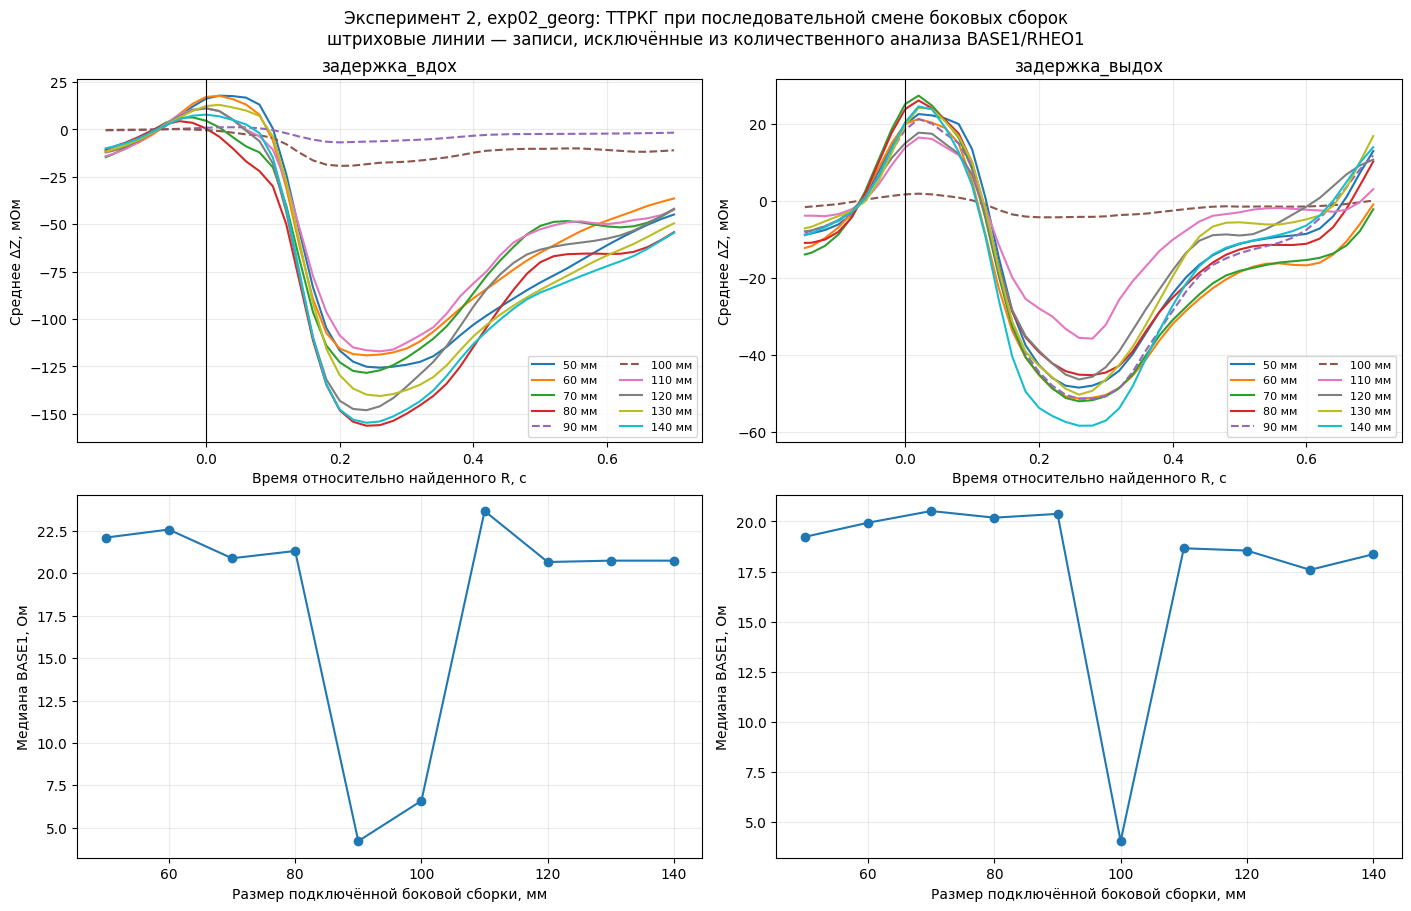

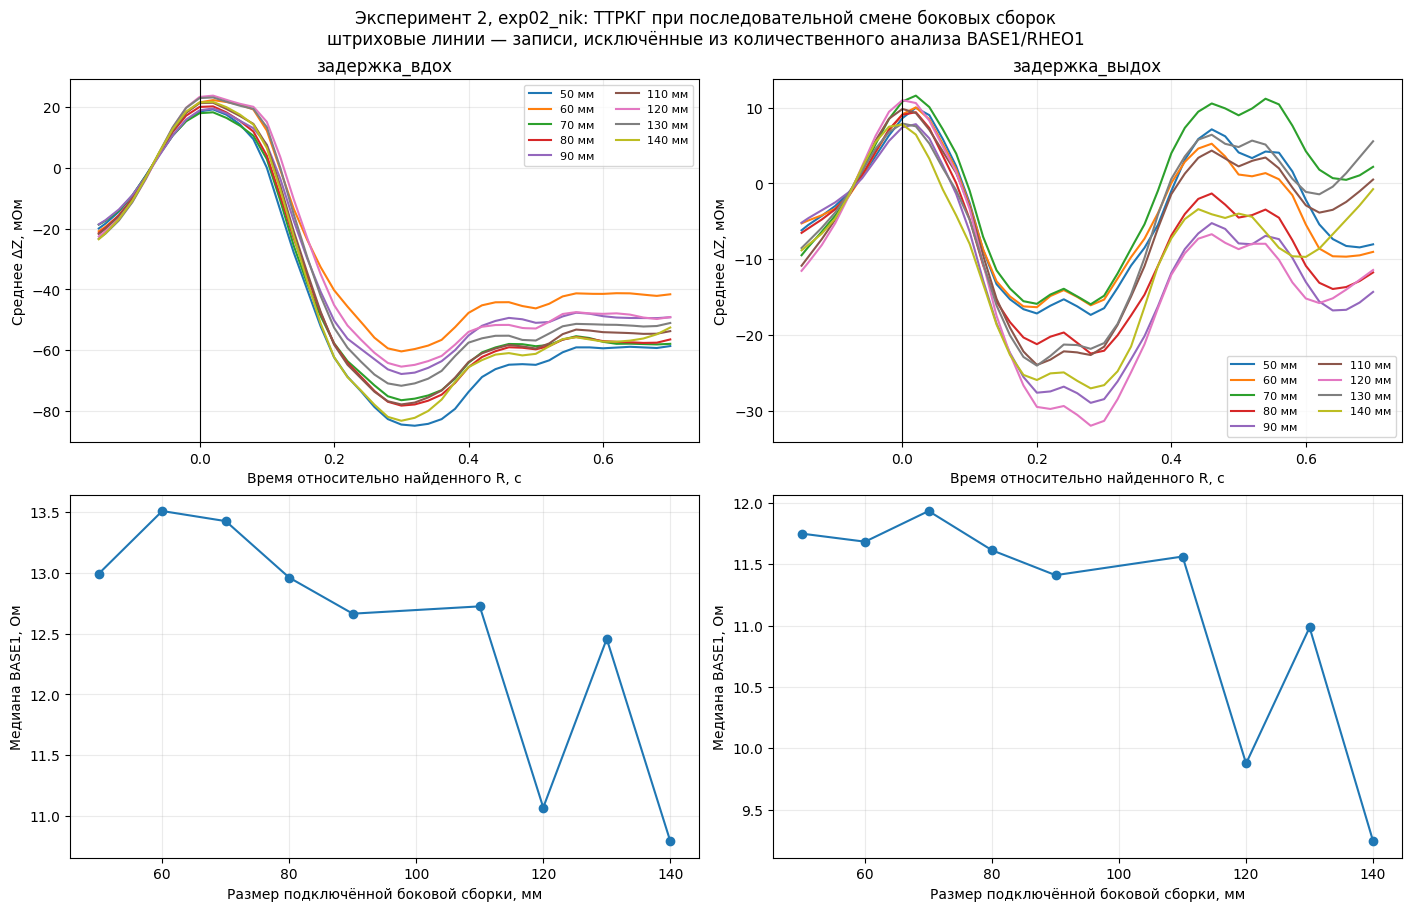

In [3]:
if REAL_MODE and outputs:
    for subject_id in sorted({row["subject_id"] for row in outputs}):
        subject_rows = [row for row in outputs if row["subject_id"] == subject_id]
        modes = ["задержка_вдох", "задержка_выдох"]
        fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)
        for column, mode in enumerate(modes):
            rows = sorted((row for row in subject_rows if row["mode"] == mode), key=lambda row: row["side_size_mm"])
            for row in rows:
                style = "--" if row["recommendation"].startswith("не_использовать") else "-"
                axes[0, column].plot(row["time_from_detected_R_s"], 1000.0 * np.asarray(row["mean_delta_z_ohm"]), style, label=f"{row['side_size_mm']} мм")
            axes[0, column].axvline(0.0, color="black", lw=0.8)
            axes[0, column].set(title=mode, xlabel="Время относительно найденного R, с", ylabel="Среднее ΔZ, мОм")
            axes[0, column].grid(alpha=0.25)
            axes[0, column].legend(ncol=2, fontsize=8)
            axes[1, column].plot([row["side_size_mm"] for row in rows], [row["baseline_z_ohm"] for row in rows], "o-")
            axes[1, column].set(xlabel="Размер подключённой боковой сборки, мм", ylabel="Медиана BASE1, Ом")
            axes[1, column].grid(alpha=0.25)
        fig.suptitle(f"Эксперимент 2, {subject_id}: ТТРКГ при последовательной смене боковых сборок\nштриховые линии — записи, исключённые из количественного анализа BASE1/RHEO1")
        fig.savefig(out_dir / f"40.01_{subject_id}_ttrkg_ensembles.png", dpi=160)
        plt.show()


## Граница результата

- Полученные кривые являются ансамблями измеренного ТТРКГ, а не оценками УО,
  ФВ или отдельного сердечного вклада.
- Внутризаписная стандартная ошибка не учитывает переклейку электродов,
  последовательность записей, состояние испытуемого, межканальное влияние и
  неизвестную групповую задержку.
- Решение `12.01` применяется адресно: две записи с непригодными
  `BASE1/RHEO1` сохраняются на графиках штриховыми линиями для диагностики, но
  не участвуют в количественных выводах.
- Пока QC-манифест имеет статус `pending_manual_review`, внешний результат
  записывается только как `exploratory_hypothesis_not_validated`.
